In [1]:
import pandas as pd
import warnings
import seaborn as sns
import numpy as np
from statsmodels.tools.eval_measures import rmse

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../Data/clean_df.csv')

In [3]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield_log,pesticides_cbrt
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37,10.508186,4.946087
1,1,Albania,Maize,1991,29068,1485.0,121.0,15.36,10.277428,4.946087
2,2,Albania,Maize,1992,24876,1485.0,121.0,16.06,10.121699,4.946087
3,3,Albania,Maize,1993,24185,1485.0,121.0,16.05,10.093529,4.946087
4,4,Albania,Maize,1994,25848,1485.0,201.0,16.96,10.160027,5.857766


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28248 entries, 0 to 28247
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28248 non-null  int64  
 1   Area                           28248 non-null  object 
 2   Item                           28248 non-null  object 
 3   Year                           28248 non-null  int64  
 4   hg/ha_yield                    28248 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28248 non-null  float64
 7   avg_temp                       28248 non-null  float64
 8   hg/ha_yield_log                28248 non-null  float64
 9   pesticides_cbrt                28248 non-null  float64
dtypes: float64(5), int64(3), object(2)
memory usage: 2.2+ MB


In [5]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [6]:
df.dropna(inplace=True)

print(df.isnull().sum())
print(df.shape)

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
hg/ha_yield_log                  0
pesticides_cbrt                  0
dtype: int64
(28242, 9)


In [7]:
df['temp_stress'] = (df['avg_temp'] - 20).abs()
df['rain_temp_ratio'] = df['average_rain_fall_mm_per_year'] / (df['avg_temp'] + 1)
df['year_trend'] = df['Year'] - df['Year'].min()
df['rainfall_category'] = pd.cut(
    df['average_rain_fall_mm_per_year'],
    bins=[0, 500, 1000, 1500, 2000, 99999],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
df['temp_category'] = pd.cut(
    df['avg_temp'],
    bins=[-99, 10, 20, 30, 99],
    labels=['Cold', 'Mild', 'Warm', 'Hot']
)

print(df.shape)
print(df.columns.tolist())

(28242, 14)
['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'hg/ha_yield_log', 'pesticides_cbrt', 'temp_stress', 'rain_temp_ratio', 'year_trend', 'rainfall_category', 'temp_category']


<Axes: >

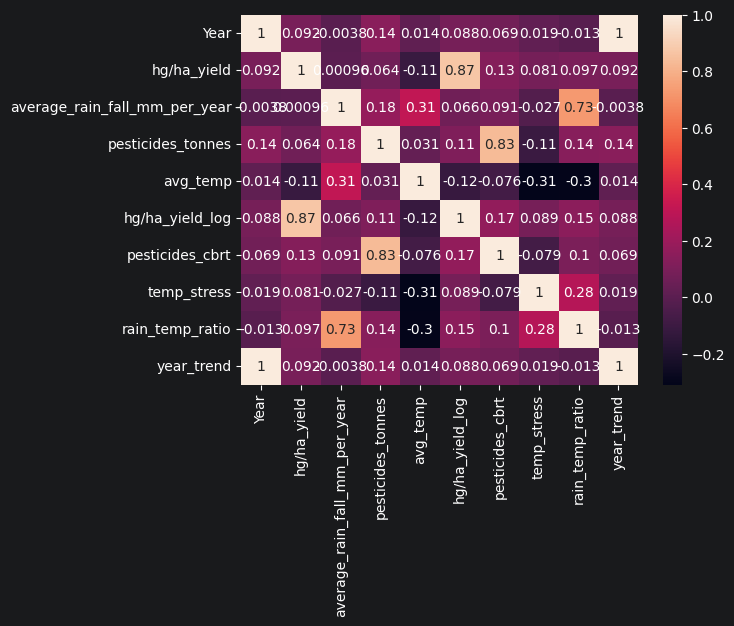

In [8]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [9]:
from sklearn.model_selection import train_test_split

x=df.drop(columns=['hg/ha_yield','hg/ha_yield_log'])
y=df['hg/ha_yield_log']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
import category_encoders as ce
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [11]:
encoder = ce.TargetEncoder(cols=['Area', 'Item'])
x_train = encoder.fit_transform(x_train, y_train)
x_test = encoder.transform(x_test)

In [12]:
x_train.columns

Index(['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp', 'pesticides_cbrt', 'temp_stress',
       'rain_temp_ratio', 'year_trend', 'rainfall_category', 'temp_category'],
      dtype='object')

In [13]:
x_train.head()

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,pesticides_cbrt,temp_stress,rain_temp_ratio,year_trend,rainfall_category,temp_category
5499,10.370866,9.604913,1997,1604.0,630.12,24.98,8.573163,4.98,61.739800,7,High,Warm
10975,10.569580,11.720014,2012,1083.0,52980.00,25.82,37.558132,5.82,40.380313,22,Medium,Warm
2003,10.875925,11.720014,2008,1292.0,268.20,25.63,6.448909,5.63,48.516710,18,Medium,Warm
22163,10.216697,10.507686,1994,494.0,6183.00,24.78,18.354100,4.78,19.162141,4,Very Low,Warm
311,9.769253,9.536569,2007,1010.0,40.00,24.24,3.419952,4.24,40.015848,17,Medium,Warm


In [14]:
numeric_cols = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_cbrt',
                'avg_temp', 'temp_stress', 'rain_temp_ratio', 'year_trend']
categorical_cols=['temp_category','rainfall_category']


In [15]:
for col in categorical_cols:
    print(x_train[col].unique())

['Warm', 'Mild', 'Cold', 'Hot']
Categories (4, object): ['Cold' < 'Mild' < 'Warm' < 'Hot']
['High', 'Medium', 'Very Low', 'Low', 'Very High']
Categories (5, object): ['Very Low' < 'Low' < 'Medium' < 'High' < 'Very High']


In [16]:
categories=[
    ['Cold','Mild' ,'Warm' ,'Hot'],
    ['Very Low','Low','Medium','High','Very High']
]

In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), numeric_cols),
    ('encode',OrdinalEncoder(categories=categories),categorical_cols)
], remainder='passthrough')

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

In [32]:
lr=LinearRegression()
rfr=RandomForestRegressor(n_estimators=50,
        max_depth=15,
        min_samples_split=10,
        n_jobs=-1,
        random_state=42)
xgb=XGBRegressor(n_estimators=200,random_state=42)

In [20]:
model1=Pipeline([
    ('preprocess',preprocessor),
    ('reg',lr)
])
model2=Pipeline([
    ('preprocess',preprocessor),
    ('reg',rfr)
])
model3=Pipeline([
    ('preprocess',preprocessor),
    ('reg',xgb)
])

In [21]:
model1.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
model2.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
model3.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
pred = model1.predict(x_test)
pred_actual = np.expm1(pred)
y_actual = np.expm1(y_test)

print(mean_absolute_error(y_actual,pred_actual))
print(mean_squared_error(y_actual,pred_actual))
print(root_mean_squared_error(y_actual,pred_actual))
print(r2_score(y_actual,pred_actual))

24042.328926522947
1978006582.8196137
44474.785922133604
0.7237658710685422


In [34]:
pred = model2.predict(x_test)
pred_actual = np.expm1(pred)
y_actual = np.expm1(y_test)

print(mean_absolute_error(y_actual,pred_actual))
print(mean_squared_error(y_actual,pred_actual))
print(root_mean_squared_error(y_actual,pred_actual))
print(r2_score(y_actual,pred_actual))

3495.905470392145
106538852.77306478
10321.765971628342
0.9851215524514721


In [28]:
pred = model3.predict(x_test)
pred_actual = np.expm1(pred)
y_actual = np.expm1(y_test)

print(mean_absolute_error(y_actual,pred_actual))
print(mean_squared_error(y_actual,pred_actual))
print(root_mean_squared_error(y_actual,pred_actual))
print(r2_score(y_actual,pred_actual))

6466.6455940763835
168023290.41370562
12962.379812893372
0.9765350794730595


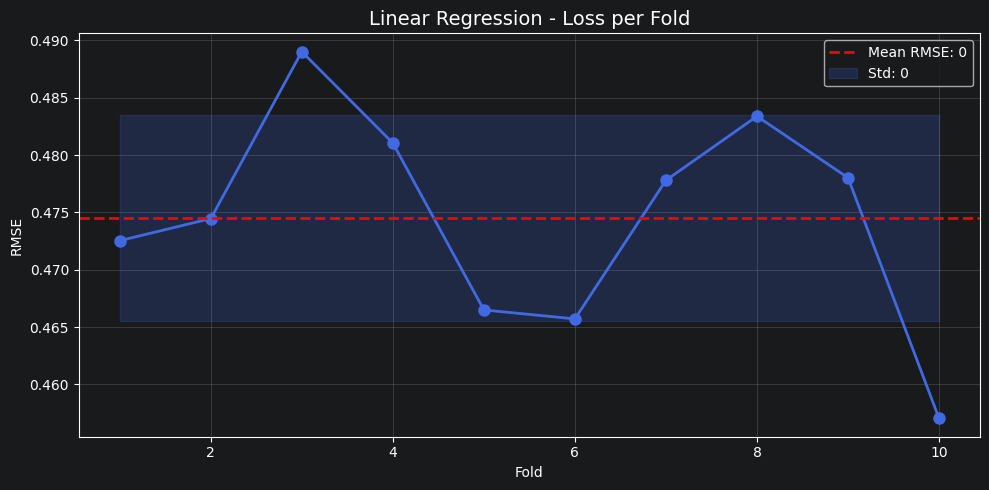

In [29]:
from sklearn.model_selection import cross_val_score,KFold
import matplotlib.pyplot as plt

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    model1, x_train, y_train,
    cv=kf,
    scoring='neg_mean_squared_error'
)
rmse_scores = np.sqrt(-scores)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), rmse_scores, marker='o',
         color='royalblue', linewidth=2, markersize=8)
plt.axhline(y=rmse_scores.mean(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mean RMSE: {rmse_scores.mean():,.0f}')
plt.fill_between(range(1, 11),
                 rmse_scores.mean() - rmse_scores.std(),
                 rmse_scores.mean() + rmse_scores.std(),
                 alpha=0.2, color='royalblue',
                 label=f'Std: {rmse_scores.std():,.0f}')
plt.title('Linear Regression - Loss per Fold', fontsize=14)
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

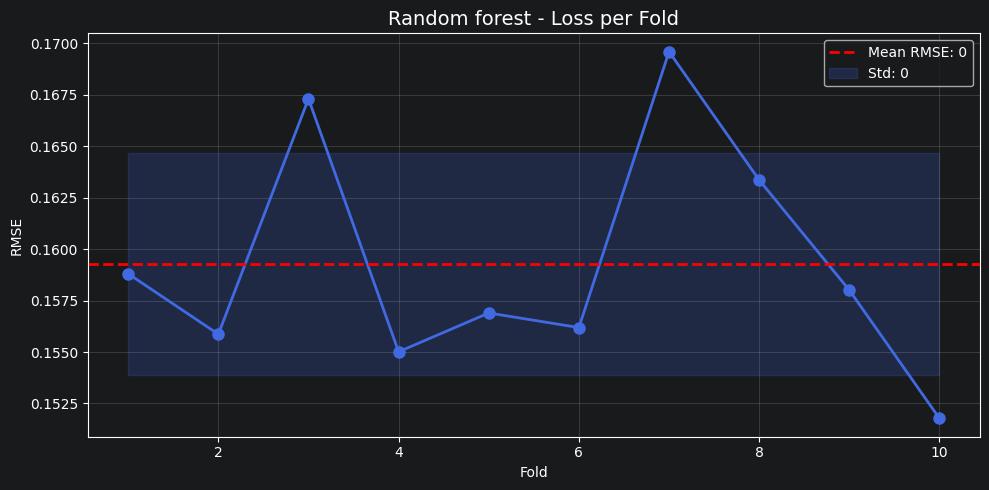

In [35]:
from sklearn.model_selection import cross_val_score,KFold
import matplotlib.pyplot as plt

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    model2, x_train, y_train,
    cv=kf,
    scoring='neg_mean_squared_error'
)
rmse_scores = np.sqrt(-scores)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), rmse_scores, marker='o',
         color='royalblue', linewidth=2, markersize=8)
plt.axhline(y=rmse_scores.mean(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mean RMSE: {rmse_scores.mean():,.0f}')
plt.fill_between(range(1, 11),
                 rmse_scores.mean() - rmse_scores.std(),
                 rmse_scores.mean() + rmse_scores.std(),
                 alpha=0.2, color='royalblue',
                 label=f'Std: {rmse_scores.std():,.0f}')
plt.title('Random forest - Loss per Fold', fontsize=14)
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

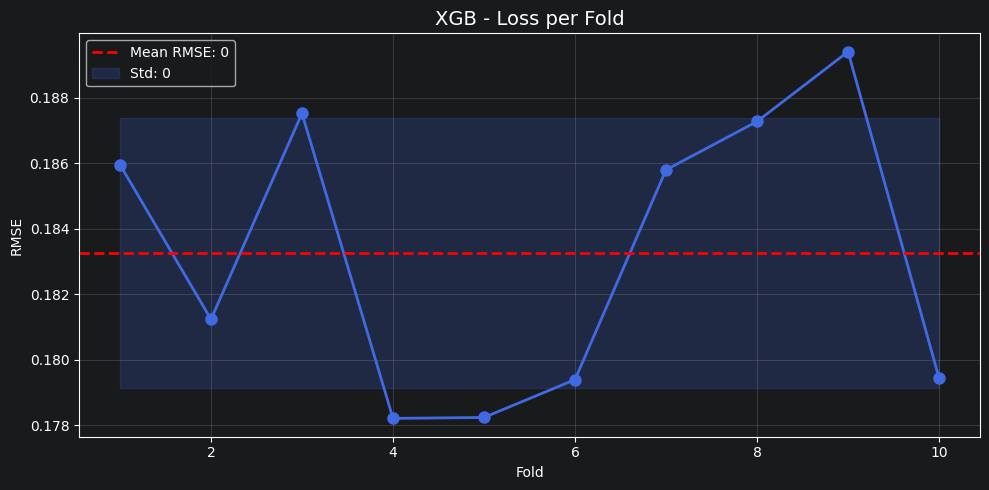

In [31]:
from sklearn.model_selection import cross_val_score,KFold
import matplotlib.pyplot as plt

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    model3, x_train, y_train,
    cv=kf,
    scoring='neg_mean_squared_error'
)
rmse_scores = np.sqrt(-scores)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), rmse_scores, marker='o',
         color='royalblue', linewidth=2, markersize=8)
plt.axhline(y=rmse_scores.mean(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mean RMSE: {rmse_scores.mean():,.0f}')
plt.fill_between(range(1, 11),
                 rmse_scores.mean() - rmse_scores.std(),
                 rmse_scores.mean() + rmse_scores.std(),
                 alpha=0.2, color='royalblue',
                 label=f'Std: {rmse_scores.std():,.0f}')
plt.title('XGB - Loss per Fold', fontsize=14)
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'reg__n_estimators': [100, 200],
    'reg__max_depth': [3, 5, 7],
    'reg__learning_rate': [0.01, 0.1, 0.2],
    'reg__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    model3,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best RMSE:   {np.sqrt(-grid_search.best_score_):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'reg__learning_rate': 0.2, 'reg__max_depth': 7, 'reg__n_estimators': 200, 'reg__subsample': 1.0}
Best RMSE:   0.1807
